# Malaria Cell Classification -- ResNet-50 + Augmented Dataset
**Backbone:** ResNet-50 pretrained on ImageNet  
**Dataset:** `augmented_horizontal_128.csv` -- 55,116 entries  
  - 27,558 original images + 27,558 horizontal-flip augmentations  
  - Images sourced from `resized_224/infected/` and `resized_224/negative/`  
  - Flips are applied **on-the-fly** in the Dataset class (no separate folder needed)  
**Key insight:** The augmented CSV was generated from `/kaggle/working` which does not
persist. The actual images live in the `224-malariadata` input dataset. This notebook
reads images from there and applies horizontal flips on-the-fly for the flip rows.


## Step 1 -- Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import functional as TF
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## Step 2 -- Configure Paths

In [2]:
# All images actually live in the resized_224 input dataset.
# We find that folder automatically.

BASE_DIR_224 = None
CSV_AUG      = None

for root, dirs, files in os.walk('/kaggle/input'):
    for fname in files:
        # Find the augmented CSV
        if fname == 'augmented_horizontal_128.csv':
            CSV_AUG = os.path.join(root, fname)
        # Find resized_224 by looking for labels_224.csv
        if fname == 'labels_224.csv':
            BASE_DIR_224 = root   # infected/ and negative/ are inside here

assert CSV_AUG is not None, (
    'augmented_horizontal_128.csv not found. '
    'Attach augmented_dataset in Notebook Settings -> Add data.'
)
assert BASE_DIR_224 is not None, (
    'labels_224.csv not found. '
    'Attach 224-malariadata in Notebook Settings -> Add data.'
)

print('Augmented CSV  :', CSV_AUG)
print('Images base dir:', BASE_DIR_224)
print('Contents       :', os.listdir(BASE_DIR_224))


Augmented CSV  : /kaggle/input/datasets/hilarychaleu/augmented-dataset/augmented_horizontal_128.csv
Images base dir: /kaggle/input/datasets/marthaagonza/224-malariadata/resized_224
Contents       : ['labels_224.csv', 'infected', 'negative']


## Step 3 -- Load CSV & Build Image Paths

In [3]:
df = pd.read_csv(CSV_AUG)
print('Shape:', df.shape)
print(df.head(6).to_string())
print()
print('Label distribution:\n', df['label'].value_counts())
print('\nType distribution:\n',  df['type'].value_counts())



FOLDER_MAP = {'Parasitized': 'infected', 'Uninfected': 'negative'}

def build_real_path(raw_path: str) -> str:
    """Map a CSV /kaggle/working path to the real /kaggle/input path."""
    after  = raw_path.split('augmented_horizontal_128/')[-1]   # e.g. Parasitized/xxx_flip1.png
    parts  = after.split('/', 1)                               # ['Parasitized', 'xxx_flip1.png']
    subfolder = FOLDER_MAP.get(parts[0], parts[0].lower())     # 'infected'
    filename  = parts[1].replace('_flip1.png', '.png')         # strip flip suffix
    return os.path.join(BASE_DIR_224, subfolder, filename)

df['real_path'] = df['filepath'].apply(build_real_path)
df['is_flip']   = (df['type'] == 'horizontal_flip').astype(int)

# label column is already int: 1=infected, 0=negative

# Verify
print('\nPath verification:')
for lv, ln in [(1, 'infected'), (0, 'negative')]:
    row = df[df['label'] == lv].iloc[0]
    print(f'  {ln}: {row["real_path"]}')
    print(f'  Exists: {os.path.isfile(row["real_path"])}')

n_valid = df['real_path'].apply(os.path.isfile).sum()
print(f'\nValid paths: {n_valid} / {len(df)}')
assert n_valid == len(df), f'Only {n_valid}/{len(df)} images found!'
print('All paths resolved correctly')


Shape: (55116, 3)
                                                                                                  filepath  label             type
0         /kaggle/working/augmented_horizontal_128/Parasitized/C99P60ThinF_IMG_20150918_141001_cell_93.png      1         original
1   /kaggle/working/augmented_horizontal_128/Parasitized/C99P60ThinF_IMG_20150918_141001_cell_93_flip1.png      1  horizontal_flip
2        /kaggle/working/augmented_horizontal_128/Parasitized/C99P60ThinF_IMG_20150918_141001_cell_133.png      1         original
3  /kaggle/working/augmented_horizontal_128/Parasitized/C99P60ThinF_IMG_20150918_141001_cell_133_flip1.png      1  horizontal_flip
4        /kaggle/working/augmented_horizontal_128/Parasitized/C101P62ThinF_IMG_20150918_151942_cell_60.png      1         original
5  /kaggle/working/augmented_horizontal_128/Parasitized/C101P62ThinF_IMG_20150918_151942_cell_60_flip1.png      1  horizontal_flip

Label distribution:
 label
1    27558
0    27558
Name: count, dt

## Step 4 -- Stratified Train / Val / Test Split (70 / 15 / 15)

In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_inf  = split['label'].sum()
    n_orig = (split['type'] == 'original').sum()
    n_flip = (split['type'] == 'horizontal_flip').sum()
    print(f'{name:5}: {len(split):>6} total | '
          f'infected={n_inf} neg={len(split)-n_inf} | '
          f'original={n_orig} flip={n_flip}')


Train:  38581 total | infected=19291 neg=19290 | original=19310 flip=19271
Val  :   8267 total | infected=4133 neg=4134 | original=4172 flip=4095
Test :   8268 total | infected=4134 neg=4134 | original=4076 flip=4192


## Step 5 -- Custom Dataset

In [6]:
class MalariaDataset(Dataset):
    """
    Loads cell images from resized_224.
    For rows where is_flip=1, applies a horizontal flip to the loaded image
    BEFORE any other transform -- faithfully reproducing the augmented dataset.
    """

    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['real_path']).convert('RGB')

        # Apply horizontal flip FIRST for flip rows
        if row['is_flip'] == 1:
            image = TF.hflip(image)

        label = torch.tensor(row['label'], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


## Step 6 -- Transforms & DataLoaders

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Dataset already has H-flips baked in via is_flip.
# Additional runtime augmentation: V-flip, rotation, colour jitter, blur, erasing.
# H-flip deliberately omitted to avoid double-flipping the flip rows.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.10)),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

BATCH_SIZE  = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    MalariaDataset(train_df, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    MalariaDataset(val_df, val_test_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    MalariaDataset(test_df, val_test_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
print(f'Batches -- train: {len(train_loader)} | '
      f'val: {len(val_loader)} | test: {len(test_loader)}')


Batches -- train: 1206 | val: 259 | test: 259


## Step 7 -- Visualise a Training Batch

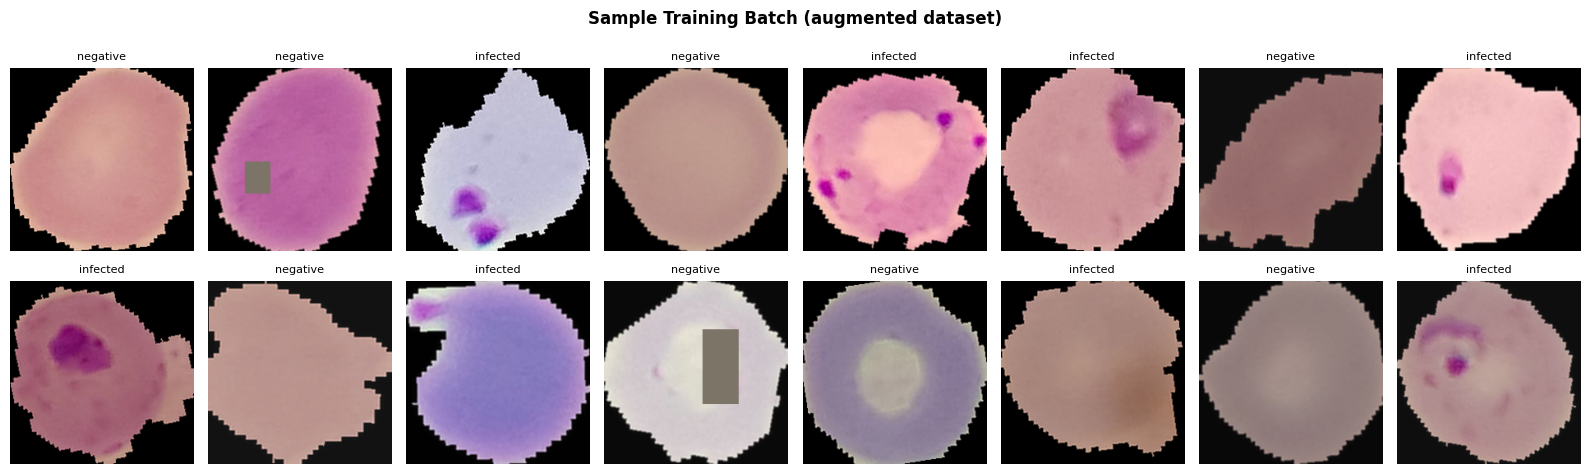

In [8]:
def denormalize(t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = t.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(denormalize(images[i]).permute(1, 2, 0).numpy())
    ax.set_title('infected' if labels[i].item() == 1 else 'negative', fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Batch (augmented dataset)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## Step 8 -- ResNet-50 Model Architecture

```
INPUT  (B, 3, 224, 224)
  Stem : Conv7x7(3->64, stride=2) -> BN -> ReLU -> MaxPool3x3
                                              -> (B, 64,  56, 56)
  Layer1 : 3x Bottleneck [64->256]           -> (B, 256, 56, 56)
  Layer2 : 4x Bottleneck [128->512, stride2] -> (B, 512, 28, 28)
  Layer3 : 6x Bottleneck [256->1024,stride2] -> (B,1024, 14, 14)
  Layer4 : 3x Bottleneck [512->2048,stride2] -> (B,2048,  7,  7)
  AdaptiveAvgPool2d(1,1) + Flatten            -> (B, 2048)

  CUSTOM HEAD
  Linear(2048, 512)
  BatchNorm1d(512)      stabilises large feature vector
  ReLU
  Dropout(0.4)
  Linear(512, 256)
  ReLU
  Dropout(0.3)
  Linear(256, 1)        single logit -> sigmoid inside BCEWithLogitsLoss

OUTPUT : P(infected)  in [0, 1]
```


In [9]:
def build_resnet50(freeze_backbone=False):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features   # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(256, 1)
    )
    return model.to(device)


model = build_resnet50(freeze_backbone=False)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'\nHead architecture:')
for name, layer in model.fc.named_children():
    print(f'  ({name}): {layer}')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


Total parameters    : 24,689,729
Trainable parameters: 24,689,729

Head architecture:
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU(inplace=True)
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=256, out_features=1, bias=True)


## Step 9 -- Loss, Optimiser & Scheduler

In [10]:
criterion = nn.BCEWithLogitsLoss()

# 3-group differential learning rates
optimizer = optim.Adam(
    [
        {'params': (list(model.layer1.parameters()) +
                    list(model.layer2.parameters()) +
                    list(model.layer3.parameters())), 'lr': 1e-5},
        {'params': model.layer4.parameters(),          'lr': 5e-5},
        {'params': model.fc.parameters(),              'lr': 1e-3},
    ],
    weight_decay=1e-3
)

# LinearWarmup(3ep) -> CosineAnnealingWarmRestarts(T_0=10)
WARMUP_EPOCHS = 3
warmup_sched = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS]
)
print('Criterion : BCEWithLogitsLoss')
print('Optimiser : Adam  wd=1e-3')
print('LRs       : layer1-3=1e-5 | layer4=5e-5 | fc=1e-3')
print('Scheduler : LinearWarmup(3ep) -> CosineWarmRestarts(T_0=10)')


Criterion : BCEWithLogitsLoss
Optimiser : Adam  wd=1e-3
LRs       : layer1-3=1e-5 | layer4=5e-5 | fc=1e-3
Scheduler : LinearWarmup(3ep) -> CosineWarmRestarts(T_0=10)


## Step 10 -- Training Loop

In [11]:
NUM_EPOCHS          = 20
SAVE_PATH           = '/kaggle/working/best_resnet50_malaria.pth'
EARLY_STOP_PATIENCE = 10

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_epoch   = 0
no_improve   = 0


def train_one_epoch(loader):
    model.train()
    total_loss, total = 0.0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total      += images.size(0)
    return total_loss / total


def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * images.size(0)
            preds       = (torch.sigmoid(logits) >= 0.5).float()
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


print(f'Training ResNet-50  |  epochs={NUM_EPOCHS}  |  patience={EARLY_STOP_PATIENCE}')
print('-' * 78)

for epoch in range(1, NUM_EPOCHS + 1):
    train_one_epoch(train_loader)
    train_loss, train_acc = evaluate(train_loader)
    val_loss,   val_acc   = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    gap  = (train_acc - val_acc) * 100
    flag = ''
    if val_acc > best_val_acc:
        best_val_acc, best_epoch, no_improve = val_acc, epoch, 0
        torch.save(model.state_dict(), SAVE_PATH)
        flag = ' <- best saved'
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train loss: {train_loss:.4f}  acc: {train_acc*100:.2f}% | '
          f'Val loss: {val_loss:.4f}  acc: {val_acc*100:.2f}%  '
          f'[gap: {gap:.2f}%]{flag}')

print(f'\nBest val acc: {best_val_acc*100:.2f}%  at epoch {best_epoch}')
print(f'Final gap   : {(history["train_acc"][-1]-history["val_acc"][-1])*100:.2f}%')


Training ResNet-50  |  epochs=20  |  patience=10
------------------------------------------------------------------------------
Epoch 01/20 | Train loss: 0.1190  acc: 95.85% | Val loss: 0.1164  acc: 95.96%  [gap: -0.11%] <- best saved
Epoch 02/20 | Train loss: 0.0896  acc: 96.86% | Val loss: 0.0838  acc: 97.00%  [gap: -0.14%] <- best saved
Epoch 03/20 | Train loss: 0.0793  acc: 97.26% | Val loss: 0.0772  acc: 97.28%  [gap: -0.02%] <- best saved
Epoch 04/20 | Train loss: 0.0759  acc: 97.39% | Val loss: 0.0725  acc: 97.53%  [gap: -0.14%] <- best saved
Epoch 05/20 | Train loss: 0.0688  acc: 97.74% | Val loss: 0.0673  acc: 97.73%  [gap: 0.01%] <- best saved
Epoch 06/20 | Train loss: 0.0662  acc: 97.69% | Val loss: 0.0632  acc: 97.79%  [gap: -0.10%] <- best saved
Epoch 07/20 | Train loss: 0.0565  acc: 97.93% | Val loss: 0.0645  acc: 97.63%  [gap: 0.31%]
Epoch 08/20 | Train loss: 0.0600  acc: 97.84% | Val loss: 0.0648  acc: 97.59%  [gap: 0.25%]
Epoch 09/20 | Train loss: 0.0457  acc: 98.35% |

## Step 11 -- Training Curves

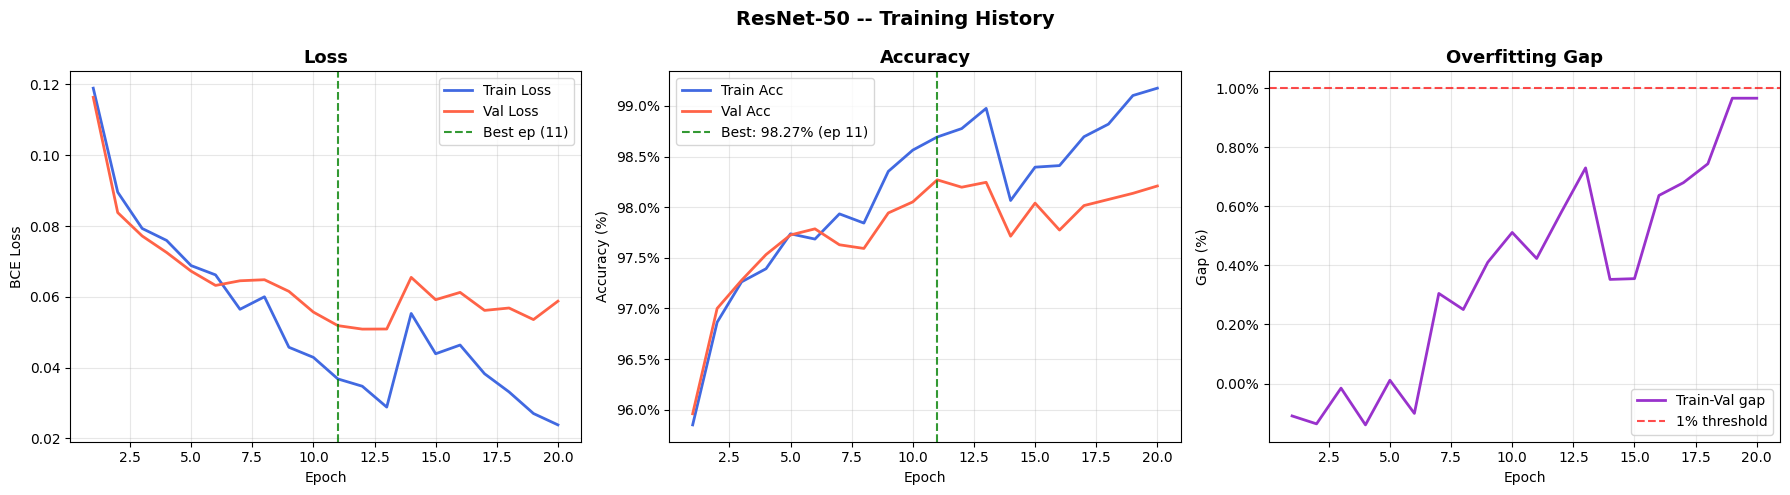

 Epoch | Train Loss |  Train Acc |  Val Loss |   Val Acc |     Gap
--------------------------------------------------------------------
     1 |     0.1190 |     95.85% |    0.1164 |    95.96% |  -0.11%
     2 |     0.0896 |     96.86% |    0.0838 |    97.00% |  -0.14%
     3 |     0.0793 |     97.26% |    0.0772 |    97.28% |  -0.02%
     4 |     0.0759 |     97.39% |    0.0725 |    97.53% |  -0.14%
     5 |     0.0688 |     97.74% |    0.0673 |    97.73% |   0.01%
     6 |     0.0662 |     97.69% |    0.0632 |    97.79% |  -0.10%
     7 |     0.0565 |     97.93% |    0.0645 |    97.63% |   0.31%
     8 |     0.0600 |     97.84% |    0.0648 |    97.59% |   0.25%
     9 |     0.0457 |     98.35% |    0.0615 |    97.94% |   0.41%
    10 |     0.0429 |     98.56% |    0.0557 |    98.05% |   0.51%
    11 |     0.0368 |     98.69% |    0.0519 |    98.27% |   0.42% <- best
    12 |     0.0347 |     98.78% |    0.0509 |    98.20% |   0.58%
    13 |     0.0288 |     98.98% |    0.0509 |    98

In [12]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
ax1, ax2, ax3 = axes

ax1.plot(epochs_ran, history['train_loss'], label='Train Loss', color='royalblue', lw=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
ax1.axvline(x=best_epoch, color='green', ls='--', alpha=0.8, label=f'Best ep ({best_epoch})')
ax1.set_title('Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ta_pct = [v*100 for v in history['train_acc']]
va_pct = [v*100 for v in history['val_acc']]
ax2.plot(epochs_ran, ta_pct, label='Train Acc', color='royalblue', lw=2)
ax2.plot(epochs_ran, va_pct, label='Val Acc',   color='tomato',    lw=2)
ax2.axvline(x=best_epoch, color='green', ls='--', alpha=0.8,
            label=f'Best: {best_val_acc*100:.2f}% (ep {best_epoch})')
ax2.set_title('Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.1f}%'))
ax2.legend(); ax2.grid(alpha=0.3)

gap_pct = [(t-v)*100 for t,v in zip(history['train_acc'], history['val_acc'])]
ax3.plot(epochs_ran, gap_pct, color='darkorchid', lw=2, label='Train-Val gap')
ax3.axhline(y=1.0, color='red', ls='--', alpha=0.7, label='1% threshold')
ax3.fill_between(epochs_ran, gap_pct, 1.0,
                 where=[g>1.0 for g in gap_pct], color='red', alpha=0.15)
ax3.set_title('Overfitting Gap', fontsize=13, fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Gap (%)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.2f}%'))
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('ResNet-50 -- Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_resnet50.png', dpi=150)
plt.show()

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>10} | "
      f"{'Val Loss':>9} | {'Val Acc':>9} | {'Gap':>7}")
print('-' * 68)
for ep,(tl,ta,vl,va) in enumerate(
        zip(history['train_loss'],history['train_acc'],
            history['val_loss'],  history['val_acc']), start=1):
    m = ' <- best' if ep == best_epoch else ''
    print(f'{ep:>6} | {tl:>10.4f} | {ta*100:>9.2f}% | '
          f'{vl:>9.4f} | {va*100:>8.2f}% | {(ta-va)*100:>6.2f}%{m}')
print(f'\nBest val acc: {best_val_acc*100:.2f}%  at epoch {best_epoch}')


## Step 12 -- Evaluation on Test Set

In [13]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        probs  = torch.sigmoid(model(images)).squeeze(1).cpu()
        preds  = (probs >= 0.5).long()
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.long().tolist())

test_acc = sum(p==l for p,l in zip(all_preds,all_labels)) / len(all_labels)
print(f'Test accuracy : {test_acc*100:.2f}%')
print(f'Best val acc  : {best_val_acc*100:.2f}%')
print()
print('Classification Report')
print('=' * 50)
print(classification_report(
    all_labels, all_preds,
    target_names=['negative (Uninfected)', 'infected (Parasitized)']
))


Test accuracy : 97.94%
Best val acc  : 98.27%

Classification Report
                        precision    recall  f1-score   support

 negative (Uninfected)       0.98      0.98      0.98      4134
infected (Parasitized)       0.98      0.98      0.98      4134

              accuracy                           0.98      8268
             macro avg       0.98      0.98      0.98      8268
          weighted avg       0.98      0.98      0.98      8268



## Step 13 -- Confusion Matrix

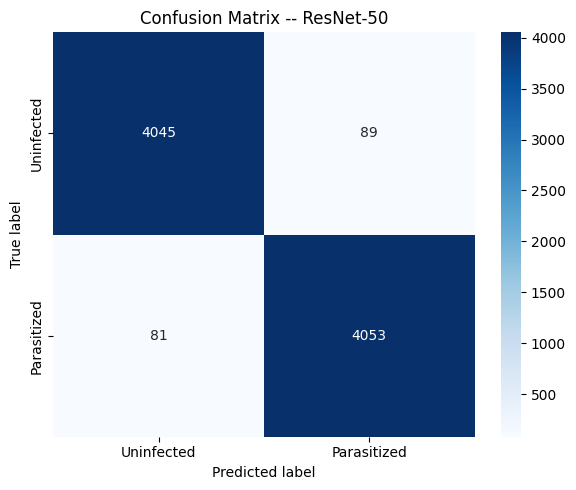

Sensitivity (infected recall): 98.04%
Specificity (negative recall): 97.85%
TP=4053  TN=4045  FP=89  FN=81


In [14]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.title('Confusion Matrix -- ResNet-50')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_resnet50.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Sensitivity (infected recall): {tp/(tp+fn)*100:.2f}%')
print(f'Specificity (negative recall): {tn/(tn+fp)*100:.2f}%')
print(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}')


## Step 14 -- Single-Image Inference

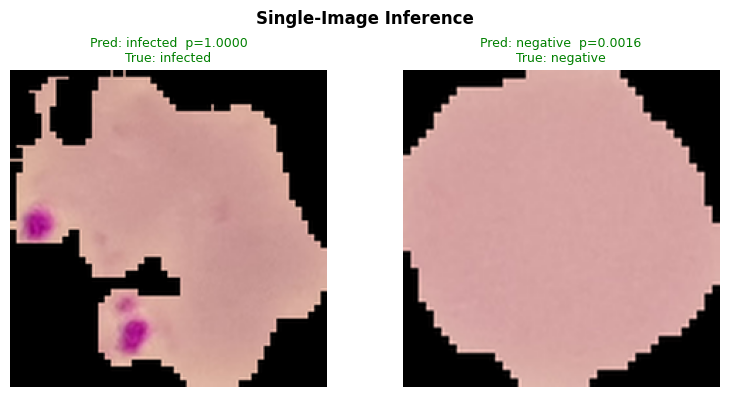

In [15]:
def predict_image(image_path, flip=False, threshold=0.5):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    if flip:
        image = TF.hflip(image)
    tensor = val_test_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(tensor)).item()
    return {'label': 'infected' if prob >= threshold else 'negative',
            'probability': round(prob, 4)}


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, lv, ln in zip(axes, [1, 0], ['infected', 'negative']):
    row    = test_df[test_df['label'] == lv].iloc[0]
    result = predict_image(row['real_path'], flip=bool(row['is_flip']))
    img    = Image.open(row['real_path'])
    if row['is_flip']:
        img = TF.hflip(img)
    ax.imshow(img)
    color = 'green' if result['label'] == ln else 'red'
    ax.set_title(f"Pred: {result['label']}  p={result['probability']:.4f}\n"
                 f"True: {ln}", fontsize=9, color=color)
    ax.axis('off')
plt.suptitle('Single-Image Inference', fontweight='bold')
plt.tight_layout(); plt.show()


---
## Quick Reference

| Step | What it does |
|------|-------------|
| 1  | Imports |
| 2  | Auto-finds CSV and resized_224 image folder via `labels_224.csv` anchor |
| 3  | Loads CSV, maps `Parasitized->infected`, strips `_flip1`, builds `real_path` |
| 4  | Stratified 70/15/15 split |
| 5  | `MalariaDataset` applies `TF.hflip()` on-the-fly for flip rows |
| 6  | Resize(224) + V-flip + rotation + jitter + blur + erasing (no H-flip -- already baked in) |
| 7  | Visualise batch |
| 8  | ResNet-50: 2048->512(BN)->256->1 with Dropout(0.4/0.3) |
| 9  | BCEWithLogitsLoss + 3-group Adam + LinearWarmup + CosineWarmRestarts |
| 10 | 30-epoch loop, early stopping patience=10, metrics in eval mode |
| 11 | 3-panel curves + epoch table |
| 12 | Classification report |
| 13 | Confusion matrix + sensitivity/specificity |
| 14 | Single-image inference |

### Why there is no separate image folder
The `augmented_horizontal_128.csv` was generated by a preprocessing script that
saved flipped copies to `/kaggle/working` -- a temporary directory that does not
persist between Kaggle sessions. This notebook reproduces the augmentation
on-the-fly inside `MalariaDataset.__getitem__()` using `TF.hflip()`, so no
separate folder is needed.
